In [1]:
import numpy as np

固有値を求めると次の通り

$\lambda = 0 ,\pm \sqrt{B^2_z + 2(B^2_x + B^2_y)} $

In [47]:


Bx=1500
By=1500
Bz=1.0e4
 
A = np.array([[Bz,          Bx-By*1j,           0],
              [Bx+By*1j,    0,                  Bx-By*1j],
              [0,           Bx+By*1j,           -Bz]])
eig, v = np.linalg.eig(A)


print(eig)

[ 1.04403065e+04+0.j -1.29630463e-13+0.j -1.04403065e+04+0.j]


In [48]:
print(v)
print(np.absolute(v))

[[ 0.97891314+0.j         -0.14367394+0.14367394j  0.        -0.02108686j]
 [ 0.14367394+0.14367394j  0.95782629+0.j         -0.14367394+0.14367394j]
 [ 0.        +0.02108686j  0.14367394+0.14367394j  0.97891314+0.j        ]]
[[0.97891314 0.20318564 0.02108686]
 [0.20318564 0.95782629 0.20318564]
 [0.02108686 0.20318564 0.97891314]]


行列を基本変形して得た固有値と、行列全体を固有方程式として解いた際の固有値に、わずかではあるが値のずれがみられる。

In [54]:
Bx=1500
By=500
Bz=1e4

H_tot = np.array([[Bz,          Bx-By*1j,       0,          -Bz*1j,         0,              0],
                  [Bx+By*1j,    0,              Bx-By*1j,   0,              -Bz*1j,         0],
                  [0,           Bx+By*1j,       -Bz,        0,              0,              -Bz*1j],
                  [Bz*1j,       0,              0,          Bz,             Bx-By*1j,       0],
                  [0,           Bz*1j,          0,          Bx+By*1j,       0,              Bx-By*1j],
                  [0,           0,              Bz*1j,      0,              Bx+By*1j,       -Bz]])
eig, eig_v = np.linalg.eig(H_tot)
print(np.absolute(eig))
print(np.absolute(eig_v))

[20246.95076596 20246.95076596 10000.         10000.
   246.95076596   246.95076596]
[[0.69858617 0.00852061 0.10910895 0.10910895 0.69858617 0.00852061]
 [0.10910895 0.10910895 0.69006556 0.69006556 0.10910895 0.10910895]
 [0.00852061 0.69858617 0.10910895 0.10910895 0.00852061 0.69858617]
 [0.69858617 0.00852061 0.10910895 0.10910895 0.69858617 0.00852061]
 [0.10910895 0.10910895 0.69006556 0.69006556 0.10910895 0.10910895]
 [0.00852061 0.69858617 0.10910895 0.10910895 0.00852061 0.69858617]]


リスト eig の1,2,4,がそれぞれ　$ \sqrt{B^2_z + 2(B^2_x + B^2_y)} ,\quad -\sqrt{B^2_z + 2(B^2_x + B^2_y)} ,\quad 0 $ に対応

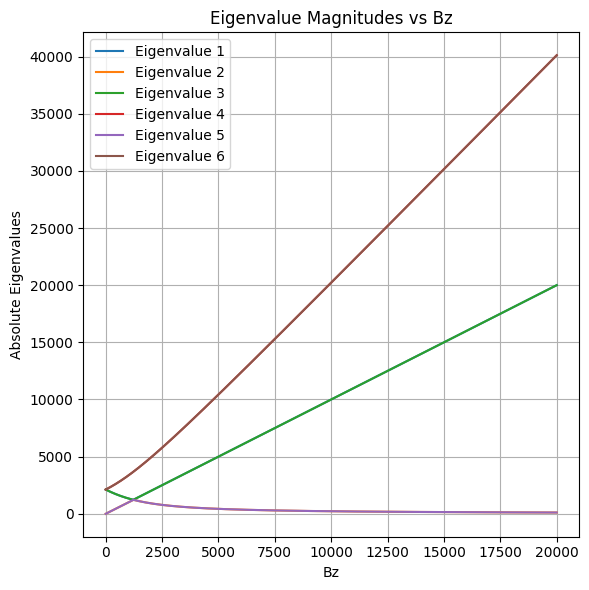

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Bx, By は固定
Bx = 1500*np.cos(30)
By = 1500*np.sin(30)

# Bz を変化させる範囲を定義
Bz_list = np.linspace(0, 20000, 2000)  # 0〜20000まで200点

# 固有値を保存するリスト
eig_abs_list = []

# # 各 Bz に対して H_tot を作って固有値の絶対値を計算
# for Bz in Bz_list:
#     H_tot = np.array([[ Bz,         Bx - By*1j,     0,           -Bz*1j,       0,           0],
#                       [ Bx + By*1j, 0,             Bx - By*1j,    0,           -Bz*1j,       0],
#                       [ 0,          Bx + By*1j,    -Bz,           0,            0,          -Bz*1j],
#                       [ Bz*1j,      0,              0,            Bz,          Bx - By*1j,   0],
#                       [ 0,          Bz*1j,          0,           Bx + By*1j,    0,          Bx - By*1j],
#                       [ 0,          0,              Bz*1j,        0,           Bx + By*1j,  -Bz]])
    
#     eig, _ = np.linalg.eig(H_tot)
#     eig_abs = np.abs(eig)  # 昇順ソート（任意）
#     eig_abs_list.append(eig_abs)

eig_abs_list = []

prev_eig = None  # 前回の固有値

for Bz in Bz_list:
    H_tot = np.array([[ Bz,         Bx - By*1j,     0,           -Bz*1j,       0,           0],
                      [ Bx + By*1j, 0,             Bx - By*1j,    0,           -Bz*1j,       0],
                      [ 0,          Bx + By*1j,    -Bz,           0,            0,          -Bz*1j],
                      [ Bz*1j,      0,              0,            Bz,          Bx - By*1j,   0],
                      [ 0,          Bz*1j,          0,           Bx + By*1j,    0,          Bx - By*1j],
                      [ 0,          0,              Bz*1j,        0,           Bx + By*1j,  -Bz]])
    
    eig, _ = np.linalg.eig(H_tot)
    eig = np.abs(eig)

    if prev_eig is None:
        # 最初はそのまま保存
        sorted_eig = eig
    else:
        # 直前の固有値に最も近いものを対応させる
        sorted_eig = np.zeros_like(eig)
        remaining = list(eig)
        for i, val in enumerate(prev_eig):
            idx = np.argmin([abs(val - r) for r in remaining])
            sorted_eig[i] = remaining.pop(idx)

    eig_abs_list.append(sorted_eig)
    prev_eig = sorted_eig.copy()

eig_abs_array = np.array(eig_abs_list)  # shape: (len(Bz_list), 6)

# プロット
plt.figure(figsize=(6, 6))
for i in range(eig_abs_array.shape[1]):
    plt.plot(Bz_list, eig_abs_array[:, i], label=f"Eigenvalue {i+1}")

plt.xlabel("Bz")
plt.ylabel("Absolute Eigenvalues")
plt.title("Eigenvalue Magnitudes vs Bz")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# print(eig_v[0])
# print(eig_v[1])
# print(eig_v[2])
# print(eig_v[3])
# print(eig_v[4])
# print(eig_v[5])

[ 7.07106767e-05-7.07106767e-05j  7.07106767e-01+0.00000000e+00j
 -2.77555756e-16+7.07106767e-01j -7.07106767e-05-7.07106767e-05j
  7.07106767e-05+7.07106767e-05j -7.07106767e-05+7.07106767e-05j]


Bzが1e4くらいで、固有ベクトルのおけるある二つの要素の組の絶対値が、他のに比べて大きくなるのが見れる。
ただし、各要素がどのスピン基底の振幅に対応しているかが不明

In [68]:
absolute_eig_v = np.abs(eig_v)
print(absolute_eig_v[1])
print(absolute_eig_v[2])
print(absolute_eig_v[4])

[0.10910895 0.10910895 0.69006556 0.69006556 0.10910895 0.10910895]
[0.00852061 0.69858617 0.10910895 0.10910895 0.00852061 0.69858617]
[0.10910895 0.10910895 0.69006556 0.69006556 0.10910895 0.10910895]


$[a_1,a_2 
a_3,a_4
a_5,a_6]$